In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname, "->", len(filenames), "files")
    for filename in filenames[:5]:
        print("   ", os.path.join(dirname, filename))


/kaggle/input -> 0 files
/kaggle/input/chain-snatching-dataset -> 0 files
/kaggle/input/chain-snatching-dataset/SlowFast_dataset -> 0 files
/kaggle/input/chain-snatching-dataset/SlowFast_dataset/val -> 0 files
/kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching -> 63 files
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching96.npz
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching78.npz
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching125.npz
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching24.npz
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Snatching/Chain_Snatching59.npz
/kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Non_Snatching -> 35 files
    /kaggle/input/chain-snatching-dataset/SlowFast_dataset/val/Non_Snatching/negative_bikepass4.npz
    /kaggle/input/chain-snatching-dataset/SlowFa

In [2]:
import numpy as np

sample_path = "/kaggle/input/chain-snatching-dataset/SlowFast_dataset/train/Snatching/Chain_Snatching143.npz"
data = np.load(sample_path)

print("Keys:", data.files)
for k in data.files:
    arr = data[k]
    print(k, arr.shape, arr.dtype)


Keys: ['slow', 'fast']
slow (3, 16, 224, 224) float32
fast (3, 64, 224, 224) float32


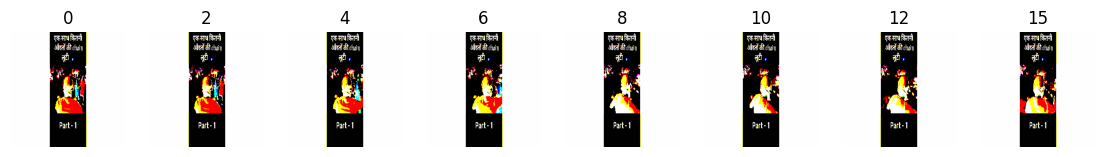

In [3]:
import matplotlib.pyplot as plt

def show_video_npz(npz_path, key=None, num_frames=8):
    data = np.load(npz_path)
    if key is None:
        key = data.files[0]
    x = data[key]

    # Fix shape to (T,H,W,C)
    if x.ndim == 4:
        if x.shape[0] in [1,3]:   # (C,T,H,W)
            x = x.transpose(1,2,3,0)
        elif x.shape[-1] in [1,3]:
            pass  # already (T,H,W,C)

    T = x.shape[0]
    idxs = np.linspace(0, T-1, num_frames).astype(int)

    plt.figure(figsize=(14,3))
    for i, idx in enumerate(idxs):
        plt.subplot(1, num_frames, i+1)
        plt.imshow(x[idx].astype('uint8'))
        plt.axis("off")
        plt.title(idx)
    plt.show()

show_video_npz(sample_path)


In [4]:
import os, glob
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SnatchingNPZDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        # class mapping
        self.class_to_idx = {"Non_Snatching": 0, "Snatching": 1}

        for cls in ["Non_Snatching", "Snatching"]:
            files = glob.glob(os.path.join(root_dir, cls, "*.npz"))
            for f in files:
                self.samples.append((f, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        d = np.load(path)
        key = d.files[0]
        x = d[key]  # video tensor

        # Ensure float tensor
        x = x.astype(np.float32)

        # normalize if uint8-like
        if x.max() > 1.5:
            x = x / 255.0

        # reshape to (C,T,H,W)
        if x.ndim == 4:
            if x.shape[-1] in [1,3]:  # (T,H,W,C)
                x = x.transpose(3,0,1,2)
            elif x.shape[0] in [1,3]: # already (C,T,H,W)
                pass

        return torch.tensor(x), torch.tensor(label)

train_root = "/kaggle/input/chain-snatching-dataset/SlowFast_dataset/train"
val_root   = "/kaggle/input/chain-snatching-dataset/SlowFast_dataset/val"

train_ds = SnatchingNPZDataset(train_root)
val_ds   = SnatchingNPZDataset(val_root)

print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))


Train samples: 328
Val samples: 98


In [5]:
import torch.nn as nn
import torchvision.models as models

class VideoBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, 2)

    def forward(self, x):
        # x: (B, C, T, H, W)
        x = x.mean(dim=2)  # temporal average -> (B,C,H,W)
        return self.backbone(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VideoBaseline().to(device)
print("Device:", device)


Device: cpu


In [6]:
from torch.optim import Adam
from tqdm import tqdm

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss/total, correct/total

for epoch in range(3):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}: train_acc={tr_acc:.3f} val_acc={va_acc:.3f}")


Epoch 1: train_acc=0.567 val_acc=0.643


Epoch 2: train_acc=0.598 val_acc=0.357


Epoch 3: train_acc=0.595 val_acc=0.643
